# Microlensing results — comprehensive EDA

Parquet from `scripts/microlensing.py` → `output/microlensing/microlensing_results_<timestamp>.parquet`.

### Column semantics
- **`fit_t0`**: Paczyński display epoch when Paczyński is *selected*; often empty for `fred` / alt-model rows while **`fit_t0_jd_*`** still use the Paczyński fit.
- **`reported_tE_days`**: Only when **`fit_ok`**; `raw_paczynski_tE_days` can still be finite when `fit_ok` is false.
- **`display_raw_paczynski_tE_days`**: Cleared when selected model is not Paczyński.
- Characterize adds many sparse columns — high NA rate is normal.


In [1]:
from __future__ import annotations

import re
from itertools import combinations
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

plt.style.use("default")
pd.set_option("display.max_columns", 40)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda x: f"{x:.6g}" if pd.notna(x) else "")


In [2]:
# Repo root: directory with pyproject.toml
NOTEBOOK_DIR = Path.cwd()
for base in (NOTEBOOK_DIR, *NOTEBOOK_DIR.parents):
    if (base / "pyproject.toml").exists():
        REPO_ROOT = base.resolve()
        break
else:
    REPO_ROOT = NOTEBOOK_DIR.resolve()

MICROLENSING_DIR = REPO_ROOT / "output" / "microlensing"
RESULTS_PATH = None  # or Path("/path/to/microlensing_results_....parquet")

if RESULTS_PATH is None:
    cand = sorted(MICROLENSING_DIR.glob("microlensing_results_*.parquet"))
    if not cand:
        raise FileNotFoundError(
            f"No microlensing_results_*.parquet under {MICROLENSING_DIR}. Set RESULTS_PATH."
        )
    RESULTS_PATH = cand[-1]
RESULTS_PATH = Path(RESULTS_PATH).expanduser().resolve()
print("REPO_ROOT:", REPO_ROOT)
print("RESULTS_PATH:", RESULTS_PATH)


REPO_ROOT: /Users/calder/code/malca
RESULTS_PATH: /Users/calder/code/malca/output/microlensing/microlensing_results_migrated_manual.parquet


In [3]:
df = pd.read_parquet(RESULTS_PATH)
print(f"shape: {df.shape[0]:,} rows x {df.shape[1]:,} cols")


shape: 19 rows x 221 cols


### Schema snapshot
`info()` memory estimate and which columns are numeric vs object.


In [4]:
df.info(verbose=False, memory_usage="deep")
print("dtypes:", df.dtypes.value_counts().to_dict())


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19 entries, 0 to 18
Columns: 221 entries, ('malca_runtime', 'candidate_id') to ('malca_runtime', 'visual_inspection_subjective_note')
dtypes: bool(12), float64(127), int64(10), object(72)
memory usage: 105.4 KB
dtypes: {dtype('float64'): 127, dtype('O'): 72, dtype('bool'): 12, dtype('int64'): 10}


### Correlation heatmap (numeric columns, finite pairs)
Keeps up to 24 columns with most non-null numeric values.


/Users/calder/code/malca/malca/plotting/lightcurve_publication.py:348: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  fig.tight_layout(pad=pad, w_pad=w_pad or pad, h_pad=h_pad or pad, rect=rect)


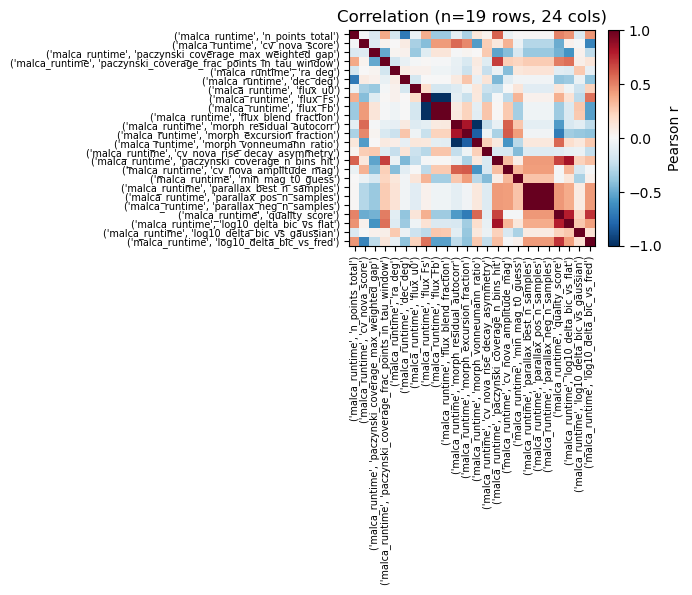

In [5]:
from malca.plotting.lightcurve_publication import (
    FIG_SINGLE_COL_HEATMAP,
    finalize_publication_figure,
)
num = df.select_dtypes(include=[np.number]).copy()
if num.shape[1] < 2:
    print("Not enough numeric columns for correlation")
else:
    counts = num.notna().sum().sort_values(ascending=False)
    keep = counts.head(min(24, len(counts))).index.tolist()
    sub = num[keep].dropna(how='all')
    if len(sub) > 5:
        c = sub.corr(min_periods=10)
        fig, ax = plt.subplots(figsize=FIG_SINGLE_COL_HEATMAP)
        im = ax.imshow(c.values, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
        ax.set_xticks(range(len(c.columns)))
        ax.set_yticks(range(len(c.columns)))
        ax.set_xticklabels(c.columns, rotation=90, fontsize=7)
        ax.set_yticklabels(c.columns, fontsize=7)
        plt.colorbar(im, ax=ax, fraction=0.046, label='Pearson r')
        ax.set_title(f'Correlation (n={len(sub)} rows, {len(keep)} cols)')
        finalize_publication_figure(plt.gcf())
        plt.show()
    else:
        print('Too few rows for correlation')


## Helpers & column groups


In [6]:
def _num(s: pd.Series) -> pd.Series:
    return pd.to_numeric(s, errors="coerce")


def _booly(s: pd.Series) -> pd.Series:
    if getattr(s.dtype, "name", str(s.dtype)) == "bool":
        return s
    m = {
        "true": True,
        "false": False,
        "1": True,
        "0": False,
        1: True,
        0: False,
    }
    out = s.map(lambda x: m.get(x, x) if pd.notna(x) else np.nan)
    return out.astype("boolean")


def bundle_from_lc_path(p: object) -> str:
    if not isinstance(p, str) or not p:
        return "(missing)"
    m = re.search(r"/runs/([^/]+)/", p)
    return m.group(1) if m else "(no /runs/<bundle>/)"


KEY_ID = "candidate_id" if "candidate_id" in df.columns else df.columns[0]

df = df.copy()
if "lc_path" in df.columns:
    df["_bundle"] = df["lc_path"].map(bundle_from_lc_path)

prefix_sets = {}
for prefix in (
    "parallax_", "external_", "ogle_ews_220326_", "ogle_ews_", "kmtnet_", "moa_",
    "gaia_alert_", "asassn_ml_", "char_", "dust_", "unwise_", "erosita_", "tns_", "alerce_",
):
    cols = [c for c in df.columns if c.startswith(prefix)]
    if cols:
        key = prefix.rstrip("_")
        prefix_sets[key] = cols

print("Column groups by prefix:")
for k, cols in sorted(prefix_sets.items(), key=lambda kv: -len(kv[1])):
    print(f"  {k:28s} {len(cols):3d}")

all_na = [c for c in df.columns if df[c].isna().all()]
print(f"\nall-null columns: {len(all_na)}")
if len(all_na) <= 50:
    print(all_na)
elif all_na:
    print(all_na[:40], "...")

constant = [c for c in df.columns if df[c].nunique(dropna=False) <= 1]
print(f"\nconstant columns: {len(constant)}")
for c in constant[:30]:
    v = df[c].iloc[0] if len(df) else None
    print(f"  {c}: {v!r}")


AttributeError: 'tuple' object has no attribute 'startswith'

## Executive summary


In [ ]:
n = len(df)
print(f"N = {n:,}  duplicate {KEY_ID}: {int(df[KEY_ID].duplicated().sum())}")

if "_bundle" in df.columns:
    print("\nRows per bundle (from lc_path):")
    display(df["_bundle"].value_counts().to_frame("n"))

if "fit_ok" in df.columns:
    ok = _booly(df["fit_ok"]).fillna(False)
    print(f"\nfit_ok rate: {ok.mean():.3f} ({ok.sum():,} / {n:,})")

if "best_model" in df.columns:
    print("\nbest_model:")
    display(df["best_model"].value_counts(dropna=False).to_frame("n"))
if "selection_mode" in df.columns:
    print("\nselection_mode:")
    display(df["selection_mode"].value_counts(dropna=False).to_frame("n"))

for col in (
    "parallax_attempted", "parallax_fit_ok", "parallax_preferred",
    "external_known_microlens", "microlens_match", "vetting_likely_known",
):
    if col not in df.columns:
        continue
    s = df[col]
    if s.dtype == object or str(s.dtype) in ("boolean", "bool"):
        vc = s.value_counts(dropna=False)
    else:
        vc = _booly(s).value_counts(dropna=False)
    print(f"\n{col}:")
    display(vc.to_frame("n"))


## Model selection — crosstabs & BIC disagreements


In [ ]:
if {"selection_mode", "best_model"}.issubset(df.columns):
    display(pd.crosstab(df["selection_mode"], df["best_model"], margins=True))

if {"best_model", "best_model_by_bic"}.issubset(df.columns):
    msel = df["best_model"].astype(str)
    mbic = df["best_model_by_bic"].astype(str)
    dis = msel.notna() & mbic.notna() & (msel != "nan") & (mbic != "nan") & (msel != mbic)
    print(f"best_model != best_model_by_bic: {dis.sum()} / {len(df)}")
    if dis.any():
        cols = [c for c in (KEY_ID, "selection_mode", "best_model", "best_model_by_bic", "best_alt_model", "fit_ok") if c in df.columns]
        display(df.loc[dis, cols].head(50))


## Fit quality — χ², ΔBIC, window


In [ ]:
chi_cols = [c for c in ("paczynski_reduced_chi2", "fit_reduced_chi2") if c in df.columns]
if chi_cols:
    display(df[chi_cols].apply(_num).describe(percentiles=[0.25, 0.5, 0.75, 0.9, 0.99]).T)

bic_cols = [c for c in df.columns if c.startswith("delta_bic_vs_")]
if bic_cols:
    display(df[bic_cols].apply(_num).describe(percentiles=[0.05, 0.5, 0.95]).T)

aux = [c for c in ("n_points_fit", "half_window_days", "shoulder_left", "shoulder_right", "n_strong_points") if c in df.columns]
if aux:
    display(df[aux].apply(_num).describe().T)


In [ ]:
from malca.plotting.lightcurve_publication import (
    figsize_from_legacy,
    finalize_publication_figure,
)
def _trim_chi(s: pd.Series) -> np.ndarray:
    x = _num(s).replace([np.inf, -np.inf], np.nan).dropna().to_numpy()
    x = x[x > 0]
    if len(x) < 5:
        return x
    return x[x <= np.nanpercentile(x, 99)]


fig, axes = plt.subplots(1, 2, figsize=figsize_from_legacy(11, 4))
for ax, col in zip(axes, ("paczynski_reduced_chi2", "fit_reduced_chi2")):
    if col not in df.columns:
        ax.set_title(f"{col} — missing")
        continue
    x = _trim_chi(df[col])
    if len(x):
        ax.hist(x, bins=40, color="steelblue", edgecolor="white")
    ax.set_title(col + " (99th pct clip)")
    ax.set_xlabel("reduced χ²")
finalize_publication_figure(plt.gcf())
plt.show()


In [ ]:
from malca.plotting.lightcurve_publication import (
    figsize_from_legacy,
    finalize_publication_figure,
)
if "fit_reduced_chi2" in df.columns and "selection_mode" in df.columns:
    sub = df.assign(_chi=_num(df["fit_reduced_chi2"]), _mode=df["selection_mode"])
    modes = sub["_mode"].value_counts().head(8).index.tolist()
    parts, labels = [], []
    for m in modes:
        p = sub.loc[sub["_mode"] == m, "_chi"].dropna()
        p = p.replace([np.inf, -np.inf], np.nan).dropna()
        p = p[(p > 0)]
        if len(p) > 10:
            hi = np.nanpercentile(p, 98)
            p = p[p <= hi]
        if len(p):
            parts.append(p.to_numpy())
            labels.append(str(m))
    if parts:
        fig, ax = plt.subplots(figsize=figsize_from_legacy(10, 4.5))
        ax.boxplot(parts, vert=True)
        ax.set_xticklabels(labels, rotation=22, ha="right")
        ax.set_ylabel("fit_reduced_chi2 (per-mode 98% clip)")
        ax.set_title("Reduced χ² by selection_mode")
        plt.xticks(rotation=22, ha="right")
        finalize_publication_figure(plt.gcf())
        plt.show()


## Timescales


In [ ]:
from malca.plotting.lightcurve_publication import (
    FIG_SINGLE_COL_SQUARE,
    figsize_from_legacy,
    finalize_publication_figure,
)
rte = _num(df["reported_tE_days"]) if "reported_tE_days" in df.columns else None
rawte = _num(df["raw_paczynski_tE_days"]) if "raw_paczynski_tE_days" in df.columns else None
dpte = _num(df["display_raw_paczynski_tE_days"]) if "display_raw_paczynski_tE_days" in df.columns else None

if rte is not None and rawte is not None:
    ok_mask = _booly(df["fit_ok"]).fillna(False) if "fit_ok" in df.columns else pd.Series(True, index=df.index)
    both = ok_mask & rte.notna() & rawte.notna()
    if both.sum():
        rel = (rte[both] - rawte[both]).abs() / rawte[both].replace(0, np.nan)
        print(f"fit_ok & finite t_E: max relative |reported-raw|/raw = {float(rel.max()):.6g}")
    m = rte.notna() & rawte.notna() & (rawte > 0) & (rte > 0)
    fig, ax = plt.subplots(figsize=FIG_SINGLE_COL_SQUARE)
    if m.any():
        fk = _booly(df["fit_ok"]).fillna(False) if "fit_ok" in df.columns else pd.Series(False, index=df.index)
        ax.scatter(rawte[m], rte[m], c=np.where(fk[m], "tab:blue", "tab:red"), s=12, alpha=0.5)
        lo = float(min(rawte[m].min(), rte[m].min()))
        hi = float(max(rawte[m].max(), rte[m].max()))
        ax.plot([lo, hi], [lo, hi], "k--", lw=1, alpha=0.5)
    ax.set_xlabel("raw_paczynski_tE_days")
    ax.set_ylabel("reported_tE_days")
    ax.set_title("t_E (blue=fit_ok)")
    ax.legend(handles=[
        Line2D([0], [0], marker="o", color="w", markerfacecolor="tab:blue", linestyle="", label="fit_ok"),
        Line2D([0], [0], marker="o", color="w", markerfacecolor="tab:red", linestyle="", label="not fit_ok"),
    ])
    finalize_publication_figure(plt.gcf())
    plt.show()

for col, lab in ((rte, "reported_tE_days"), (rawte, "raw_paczynski_tE_days"), (dpte, "display_raw_paczynski_tE_days")):
    if col is None:
        continue
    x = col.replace([np.inf, -np.inf], np.nan).dropna()
    x = x[x > 0]
    if len(x) < 2:
        continue
    fig, ax = plt.subplots(figsize=figsize_from_legacy(6, 3.5))
    ax.hist(x, bins=32, color="darkseagreen", edgecolor="white")
    ax.set_xlabel(f"{lab} (days)")
    plt.title(lab)
    finalize_publication_figure(plt.gcf())
    plt.show()


## Seeds & epochs


In [ ]:
from malca.plotting.lightcurve_publication import (
    FIG_SINGLE_COL_MEDIUM,
    FIG_SINGLE_COL_SQUARE,
    finalize_publication_figure,
)
if {"seed_t0_guess", "fit_t0_jd_minus_2450000"}.issubset(df.columns):
    a, b = _num(df["seed_t0_guess"]), _num(df["fit_t0_jd_minus_2450000"])
    m = a.notna() & b.notna()
    if m.sum():
        fig, ax = plt.subplots(figsize=FIG_SINGLE_COL_SQUARE)
        ax.scatter(a[m], b[m], s=10, alpha=0.45, c="tab:purple")
        lo = float(np.nanpercentile(np.r_[a[m], b[m]], 1))
        hi = float(np.nanpercentile(np.r_[a[m], b[m]], 99))
        ax.plot([lo, hi], [lo, hi], "k--", lw=1)
        ax.set_xlabel("seed_t0_guess")
        ax.set_ylabel("fit_t0_jd_minus_2450000 (Pacz)")
        ax.set_title("Seed vs Paczyński t0")
        finalize_publication_figure(plt.gcf())
        plt.show()

if {"pipeline_jump_t0", "seed_t0_guess"}.issubset(df.columns):
    pj, sg = _num(df["pipeline_jump_t0"]), _num(df["seed_t0_guess"])
    m = pj.notna() & sg.notna()
    if m.sum() > 5:
        fig, ax = plt.subplots(figsize=FIG_SINGLE_COL_MEDIUM)
        ax.scatter(pj[m], sg[m], s=10, alpha=0.45)
        ax.set_xlabel("pipeline_jump_t0")
        ax.set_ylabel("seed_t0_guess")
        plt.title("Jump vs seed t0")
        finalize_publication_figure(plt.gcf())
        plt.show()

if "seed_method" in df.columns:
    display(df["seed_method"].value_counts(dropna=False).to_frame("n"))


## ΔBIC scatter


In [ ]:
from malca.plotting.lightcurve_publication import (
    figsize_from_legacy,
    finalize_publication_figure,
)
if {"delta_bic_vs_flat", "delta_bic_vs_gaussian"}.issubset(df.columns):
    x = _num(df["delta_bic_vs_flat"])
    y = _num(df["delta_bic_vs_gaussian"])
    m = np.isfinite(x) & np.isfinite(y)
    if m.sum():
        fig, ax = plt.subplots(figsize=figsize_from_legacy(6.5, 5.5))
        ax.scatter(x[m], y[m], s=12, alpha=0.45, c="tab:blue")
        ax.axvline(0, color="k", lw=0.8, ls="--")
        ax.axhline(0, color="k", lw=0.8, ls="--")
        ax.set_xlabel("ΔBIC vs flat")
        ax.set_ylabel("ΔBIC vs gaussian")
        plt.title("BIC margins (best seed)")
        finalize_publication_figure(plt.gcf())
        plt.show()

if "delta_bic_vs_flat" in df.columns:
    d = _num(df["delta_bic_vs_flat"])
    thr = 100.0
    strong = d > thr
    print(f"delta_bic_vs_flat > {thr}: {int(strong.sum())}")
    if strong.any():
        cols = [c for c in (KEY_ID, "best_model", "fit_ok", "paczynski_reduced_chi2", "reported_tE_days", "delta_bic_vs_flat") if c in df.columns]
        display(df.loc[strong, cols].sort_values("delta_bic_vs_flat", ascending=False).head(25))


## Parallax


In [ ]:
from malca.plotting.lightcurve_publication import (
    FIG_SINGLE_COL_SQUARE,
    finalize_publication_figure,
)
pcols = [c for c in df.columns if c.startswith("parallax_")]
if not pcols:
    print("No parallax_* columns")
else:
    if "parallax_status" in df.columns:
        display(df["parallax_status"].value_counts(dropna=False).to_frame("n"))
    keyn = [
        c for c in pcols
        if any(k in c for k in ("_tE_days", "chi2", "_bic", "piE", "_u0", "acceptance", "_samples"))
        and c not in ("parallax_warning",)
    ]
    keyn = [c for c in keyn if c in df.columns][:32]
    if keyn:
        display(df[keyn].apply(_num).describe(percentiles=[0.5, 0.9]).T)

if {"parallax_best_tE_days", "raw_paczynski_tE_days"}.issubset(df.columns):
    a, b = _num(df["parallax_best_tE_days"]), _num(df["raw_paczynski_tE_days"])
    m = a.notna() & b.notna() & (a > 0) & (b > 0)
    if m.sum() > 3:
        fig, ax = plt.subplots(figsize=FIG_SINGLE_COL_SQUARE)
        ax.scatter(b[m], a[m], s=14, alpha=0.5)
        lo = float(min(b[m].min(), a[m].min()))
        hi = float(max(b[m].max(), a[m].max()))
        ax.plot([lo, hi], [lo, hi], "k--", lw=1)
        ax.set_xlabel("raw_paczynski_tE_days")
        ax.set_ylabel("parallax_best_tE_days")
        plt.title("Parallax vs PSPL t_E")
        finalize_publication_figure(plt.gcf())
        plt.show()


## External catalog & surveys


In [ ]:
from malca.plotting.lightcurve_publication import (
    figsize_from_legacy,
    finalize_publication_figure,
)
if "external_known_microlens" in df.columns:
    ext = _booly(df["external_known_microlens"]).fillna(False)
    print(f"external_known_microlens: {int(ext.sum())} / {len(df)}")
    if ext.any():
        ecols = [c for c in df.columns if c.startswith("external_best_microlens")]
        display(df.loc[ext, [KEY_ID] + ecols].head(25))
    if ext.any() and "external_best_microlens_delta_t0_days" in df.columns:
        d0 = _num(df.loc[ext, "external_best_microlens_delta_t0_days"]).dropna()
        if len(d0):
            fig, ax = plt.subplots(figsize=figsize_from_legacy(5, 3.5))
            ax.hist(np.log10(d0.clip(lower=1e-6)), bins=25, color="coral", edgecolor="white")
            ax.set_xlabel("log10(Δt0 days) vs external catalog")
            plt.title("External microlens time residuals")
            finalize_publication_figure(plt.gcf())
            plt.show()

for col, lab in (
    ("ogle_ews_event_id", "OGLE EWS"),
    ("ogle_ews_220326_event_id", "OGLE 220326"),
    ("kmtnet_event_id", "KMTNet"),
    ("moa_event_id", "MOA"),
):
    if col not in df.columns:
        continue
    nn = df[col].notna() & (df[col].astype(str).str.strip().str.len() > 0)
    print(f"{lab}: {int(nn.sum())} with {col}")


## SIMBAD / VSX / Gaia / ZTF


In [ ]:
for col, topn in (
    ("simbad_otype", 25),
    ("vsx_class", 20),
    ("gaia_var_class", 20),
    ("ztf_var_type", 20),
    ("catalog_source", 15),
):
    if col not in df.columns:
        continue
    print(f"\n{col} (top {topn}):")
    display(df[col].astype(str).value_counts(dropna=False).head(topn).to_frame("n"))

if "asassn_ml_match" in df.columns:
    display(df["asassn_ml_match"].value_counts(dropna=False).to_frame("n"))
if "gaia_alert_lookup_status" in df.columns:
    display(df["gaia_alert_lookup_status"].value_counts(dropna=False).to_frame("n"))
if "gaia_alert_microlens_like" in df.columns:
    display(_booly(df["gaia_alert_microlens_like"]).value_counts(dropna=False).to_frame("n"))


## Catalog & module reference (`--crossmatch`)



When **`scripts/microlensing.py`** runs with **`--crossmatch`**, enrichment is mainly:



1. **`malca.enrichment.characterize.characterize_candidates_df`** — Gaia multi-wavelength context, VSX crossmatch, optional BANYAN Σ, IPHAS, nearest **star-forming regions**, **open clusters**, unWISE/unTimely, **3D dust** (`A_v_3d` / `ebv_3d`), StarHorse, etc.

2. **`malca.enrichment.vetting.vet_candidates`** — **post-review vetting** (what the log calls `POST-REVIEW VETTING`). That step is the one that prints the **VETTING SUMMARY** block.



**Vetting (`vet_candidates`) — complete list of catalog / checks** (all that can appear in the summary; each may be skipped if toggled off or if prerequisites are missing):



- **SIMBAD** — CDS XMatch → `nearest_simbad_object`, `simbad_otype`, `simbad_sep_arcsec`, …

- **Gaia DR3 variability** — `vari_summary` / classifier → Gaia var columns (e.g. `gaia_var_class`)

- **Gaia epoch photometry** — per-source epoch stats (vetting adds time-series-related fields)

- **ASAS-SN variable catalog** (TAP) → `asassn_var_name`, `asassn_var_type`, …

- **ZTF variables** (TAP) → `ztf_var_type`, …

- **TNS** — only if local `input/tns_public_objects.csv` / `input/tns_sne.csv` are loaded → `tns_name`, …

- **Gaia EB parameters** — only for ECL-classified Gaia sources in that vetting path

- **ALeRCE** (ZTF broker) → e.g. `alerce_lc_class`, …

- **eROSITA** X-ray crossmatch → `xray_det`, `xray_flux`, `xray_sep_arcsec`

- **PM consistency** — proper motion vs. open-cluster mean when `cluster_name` / membership justify it → `pm_cluster_offset_sigma`



**`vetting_likely_known`** is computed at the end of vetting from combinations of the above (plus microlens matches, etc.); see `malca/vetting.py` near the “Likely known” printout.



**Not part of that vetting block:** the script’s separate **published microlensing event** crossmatch (`external_*`, `ogle_*`, `kmtnet_*`, `moa_*`) and optional **Gaia Alerts** table — merged later in `microlensing.py`.

The **terminal** block under `VETTING SUMMARY` (match counts per module, `Likely known` / `Potentially new`) is the authoritative checklist for that run; modules print “skipping” when inputs are missing (e.g. TNS CSVs, ECL Gaia sources, enough cluster members for PM).


## Astronomy: known variables & catalog provenance

After **`vet_candidates`**, **`vetting_likely_known`** is true if any archival indicator suggests a known variable or transient: Gaia DR3 variability class, ASAS-SN variable type, VSX class, ZTF var type, TNS name, ALeRCE LC class, microlensing-catalog crossmatch, or SIMBAD type plausibly variable (very rough otype keyword match; see `vetting.py`).

**`catalog_source`** (when present) comes from earlier filtering / periodic-catalog tagging, not from the live TAP vetting step.

In [ ]:
def _has_str(col: str) -> pd.Series:
    if col not in df.columns:
        return pd.Series(False, index=df.index)
    s = df[col]
    if s.dtype == object or str(s.dtype).startswith('string'):
        return s.fillna('').astype(str).str.strip().ne('')
    return s.notna()

def _sim_simbad_var(series: pd.Series) -> pd.Series:
    """Loose analogue of vetting SIMBAD variable filter."""
    def one(x) -> bool:
        s = str(x).strip()
        if not s:
            return False
        if 'V*' in s:
            return True
        keys = ('EB*', 'YSO', 'SN', 'Nova', 'Catac', 'RR*', 'Cepheid', 'Mira', 'BYDra', 'RSCVn', 'Symbiotic',
                'ELL', 'Blazar', 'QSO', 'AGN', 'Em*', 'Be*', 'RS*', 'Orion')
        low = s.lower()
        return any(str(k).lower() in low for k in keys)
    return series.map(one)

contributors = {
    'gaia_var_class': _has_str('gaia_var_class'),
    'asassn_var_type': _has_str('asassn_var_type'),
    'vsx_class': _has_str('vsx_class'),
    'ztf_var_type': _has_str('ztf_var_type'),
    'tns_name': _has_str('tns_name'),
    'alerce_lc_class': _has_str('alerce_lc_class'),
}
if 'microlens_match' in df.columns:
    contributors['microlens_match'] = _booly(df['microlens_match']).fillna(False)
if 'nearest_simbad_object' in df.columns:
    contributors['has_simbad_name'] = _has_str('nearest_simbad_object')
if 'simbad_otype' in df.columns:
    contributors['simbad_var_like_otype'] = _sim_simbad_var(df['simbad_otype'].fillna('').astype(str))

con_df = pd.DataFrame(contributors)
print('Rows with each contributor (counts are not mutually exclusive):')
display(con_df.sum().sort_values(ascending=False).to_frame('n_rows'))
n_flags = con_df.sum(axis=1)
print('\nHow many contributor flags per candidate:')
display(n_flags.value_counts().sort_index().to_frame('n_candidates'))

if 'vetting_likely_known' in df.columns:
    vk = _booly(df['vetting_likely_known']).fillna(False)
    recon = con_df.any(axis=1)
    print('\nvetting_likely_known vs OR(contributors above):')
    display(pd.crosstab(vk, recon, margins=True, rownames=['vetting'], colnames=['recon_OR']))

if 'catalog_source' in df.columns:
    print('\ncatalog_source:')
    display(df['catalog_source'].fillna('').astype(str).replace('', '(empty)').value_counts(dropna=False).head(25).to_frame('n'))

## Young populations: moving groups, open clusters, star-forming regions, Hα

**BANYAN Σ** — association with young moving groups / young associations (`banyan_best_assoc`, `banyan_field_prob`).

**Open clusters** — `cluster_name` (+ distance/age when present).

**SFR catalogue** — proximity to catalogued star-forming regions (`sfr_name`, `sfr_sep_arcmin`).

**IPHAS** — emission-line / Hα-excess style flag (`iphas_ha_excess`) where the module ran.

In [ ]:
from malca.plotting.lightcurve_publication import (
    figsize_from_legacy,
    finalize_publication_figure,
)
char_status_cols = sorted([c for c in df.columns if c.startswith('char_status_')])
if char_status_cols:
    print('char_status_* summaries:')
    for c in char_status_cols:
        print(f'\n{c}')
        display(df[c].astype(str).value_counts(dropna=False).head(10).to_frame('n'))
else:
    print('No char_status_* columns.')

if {'banyan_best_assoc', 'banyan_field_prob'}.issubset(df.columns):
    assoc = df['banyan_best_assoc'].fillna('').astype(str).str.strip()
    named = assoc.ne('') & ~assoc.str.lower().isin({'nan', 'none', 'field'})
    print(f'\nBANYAN named association: {int(named.sum())} / {len(df)}')
    if named.any():
        cols = [KEY_ID, 'banyan_best_assoc', 'banyan_field_prob']
        cols += [c for c in ('mw_line_of_sight_region', 'gal_l_deg', 'gal_b_deg') if c in df.columns]
        display(df.loc[named, cols].head(25))
        bp = _num(df.loc[named, 'banyan_field_prob']).dropna()
        if len(bp) > 10:
            fig, ax = plt.subplots(figsize=figsize_from_legacy(5.5, 3.2))
            ax.hist(bp, bins=20, color='tab:cyan', edgecolor='white')
            ax.set_xlabel('banyan_field_prob')
            ax.set_title('Field-star probability (named-assoc rows)')
            finalize_publication_figure(plt.gcf())
            plt.show()

if 'cluster_name' in df.columns:
    cn = df['cluster_name'].fillna('').astype(str).str.strip()
    in_cl = cn.ne('')
    print(f'\nOpen cluster match: {int(in_cl.sum())} / {len(df)}')
    if in_cl.any():
        display(cn[in_cl].value_counts().head(15).to_frame('n'))
        extra = [c for c in ('cluster_dist_pc', 'cluster_age_myr', 'cluster_membership_prob') if c in df.columns]
        display(df.loc[in_cl, [KEY_ID, 'cluster_name'] + extra].head(20))

if 'sfr_name' in df.columns:
    sn = df['sfr_name'].fillna('').astype(str).str.strip()
    near_sfr = sn.ne('')
    print(f'\nSFR catalogue proximity: {int(near_sfr.sum())} / {len(df)}')
    if near_sfr.any():
        ocols = [KEY_ID, 'sfr_name'] + (['sfr_sep_arcmin'] if 'sfr_sep_arcmin' in df.columns else [])
        ocols += [c for c in ('mw_line_of_sight_region', 'vetting_likely_known', 'fit_ok') if c in df.columns]
        tmp = df.loc[near_sfr, ocols].copy()
        if 'sfr_sep_arcmin' in tmp.columns:
            tmp = tmp.sort_values('sfr_sep_arcmin')
        display(tmp.head(25))
        display(sn[near_sfr].value_counts().head(12).to_frame('n'))

if 'iphas_ha_excess' in df.columns:
    raw = df['iphas_ha_excess']
    if raw.dtype == bool or str(raw.dtype) == 'boolean':
        hot = raw.fillna(False)
    else:
        hot = pd.to_numeric(raw, errors='coerce') > 0
        hot = hot | raw.astype(str).str.lower().isin({'true', '1', 't'})
    print(f'\nIPHAS Hα excess: {int(hot.fillna(False).sum())} / {len(df)}')
    if hot.any():
        sc = [KEY_ID] + [c for c in ('iphas_r_ha', 'iphas_r_i', 'simbad_otype', 'gaia_var_class', 'sfr_name') if c in df.columns]
        display(df.loc[hot.fillna(False), sc].head(20))


## Galactic line-of-sight x known-variable flag
Bulge vs disk vs Cloud fields have different contamination from intrinsic variables and crowding.

In [ ]:
if {'mw_line_of_sight_region', 'vetting_likely_known'}.issubset(df.columns):
    reg = df['mw_line_of_sight_region'].fillna('(missing)').astype(str)
    vk = _booly(df['vetting_likely_known']).fillna(False)
    print('Counts:')
    display(pd.crosstab(reg, vk, margins=True))
    print('Row % known (vetting_likely_known):')
    display((pd.crosstab(reg, vk, normalize='index') * 100).round(1))

if {'mw_line_of_sight_region', 'fit_ok'}.issubset(df.columns):
    reg = df['mw_line_of_sight_region'].fillna('(missing)').astype(str)
    fo = _booly(df['fit_ok']).fillna(False)
    display(fo.groupby(reg).mean().sort_values(ascending=False).to_frame('frac_fit_ok'))

if 'simbad_otype' in df.columns:
    pat = r'YSO|Orion|T Tau|Herbig|Em\*|PMS|Ae/Be|TTauri|CTTS|WTTS'
    yso_like = df['simbad_otype'].fillna('').astype(str).str.contains(pat, case=False, regex=True, na=False)
    print(f'\nSIMBAD otype YSO/PMS/emission-like (regex): {int(yso_like.sum())} / {len(df)}')
    if yso_like.any():
        cols = [c for c in (KEY_ID, 'simbad_otype', 'nearest_simbad_object', 'sfr_name', 'cluster_name',
                'vetting_likely_known', 'fit_ok', 'mw_line_of_sight_region') if c in df.columns]
        display(df.loc[yso_like, cols].head(25))

## Dust & distance (optional characterize modules)
`A_v_3d`, `ebv_3d` when **dustmaps** query ran. Distances from Gaia photometry / parallax or StarHorse when those columns exist.

In [ ]:
from malca.plotting.lightcurve_publication import (
    FIG_SINGLE_COL_LC_WIDE,
    finalize_publication_figure,
)
dust_cols = [c for c in ('A_v_3d', 'ebv_3d', 'dust_sigma', 'dust_max_dist_kpc') if c in df.columns]
if dust_cols:
    display(df[dust_cols].apply(_num).describe().T)
    for c in dust_cols:
        x = _num(df[c]).replace([np.inf, -np.inf], np.nan).dropna()
        if len(x) > 3:
            fig, ax = plt.subplots(figsize=FIG_SINGLE_COL_LC_WIDE)
            ax.hist(x, bins=28, color='peru', edgecolor='white')
            ax.set_title(c)
            finalize_publication_figure(plt.gcf())
            plt.show()
else:
    print('No 3D dust columns in this table.')

dist_like = [c for c in df.columns if c in ('distance_gspphot', 'parallax', 'gaia_parallax')]
dist_like += [c for c in df.columns if c.startswith('starhorse_') and df[c].dtype != object][:15]
dist_like = sorted(set(dist_like))
if dist_like:
    display(df[dist_like].apply(_num).describe().T.head(20))


## Multiwavelength context (X-ray, mid-IR)

**eROSITA** — `xray_det` / `xray_flux` / `xray_sep_arcsec` when the vetting crossmatch ran.

**unWISE** — variability z-scores and flags when `characterize` queried unTimely (e.g. `unwise_w1_var`).


In [ ]:
from malca.plotting.lightcurve_publication import (
    FIG_SINGLE_COL_LC_WIDE,
    finalize_publication_figure,
)
if 'xray_det' in df.columns:
    xd = _booly(df['xray_det']).fillna(False)
    print(f'eROSITA detection (xray_det): {int(xd.sum())} / {len(df)}')
    if xd.any() and 'xray_flux' in df.columns:
        fl = _num(df.loc[xd, 'xray_flux']).dropna()
        if len(fl):
            fig, ax = plt.subplots(figsize=FIG_SINGLE_COL_LC_WIDE)
            ax.hist(np.log10(fl.clip(lower=1e-20)), bins=22, color='0.35', edgecolor='white')
            ax.set_xlabel('log10(xray_flux)')
            plt.title('eROSITA flux (detected rows)')
            finalize_publication_figure(plt.gcf())
            plt.show()
    show = [KEY_ID] + [c for c in ('xray_sep_arcsec', 'xray_flux', 'simbad_otype', 'mw_line_of_sight_region') if c in df.columns]
    if xd.any():
        display(df.loc[xd, show].head(20))

uw = [c for c in df.columns if c.startswith('unwise_') and c not in ('char_status_unwise',)]
if uw:
    print('\nunWISE-related columns (sample stats):')
    boolish = [c for c in uw if 'var' in c or c.endswith('_flag')]
    for c in boolish[:6]:
        if c not in df.columns:
            continue
        print(c, _booly(df[c]).fillna(False).value_counts(dropna=False).to_dict())
    numuw = [c for c in uw if c not in boolish][:8]
    if numuw:
        display(df[numuw].apply(_num).describe().T)
else:
    print('No unwise_* columns.')


## Environment overlay: SFR, cluster, or BANYAN (combined)
Single mask for “interesting” **Galactic / youth** context when vetting microlensing-shaped events.

In [ ]:
env_mask = pd.Series(False, index=df.index)
bits = {}
if 'sfr_name' in df.columns:
    bits['near_SFR'] = df['sfr_name'].fillna('').astype(str).str.strip().ne('')
if 'cluster_name' in df.columns:
    bits['open_cluster'] = df['cluster_name'].fillna('').astype(str).str.strip().ne('')
if 'banyan_best_assoc' in df.columns:
    a = df['banyan_best_assoc'].fillna('').astype(str).str.strip()
    bits['banyan_named'] = a.ne('') & ~a.str.lower().isin({'field', 'nan', 'none'})
for k, s in bits.items():
    env_mask = env_mask | s.fillna(False)

print(f'Any SFR / cluster / BANYAN hit: {int(env_mask.sum())} / {len(df)}')
if bits:
    display(pd.DataFrame({k: v.fillna(False) for k, v in bits.items()}).sum().to_frame('n'))

cols = [c for c in (KEY_ID, 'sfr_name', 'sfr_sep_arcmin', 'cluster_name', 'cluster_dist_pc',
        'banyan_best_assoc', 'banyan_field_prob', 'mw_line_of_sight_region', 'vetting_likely_known',
        'fit_ok', 'best_model', 'paczynski_reduced_chi2') if c in df.columns]
if env_mask.any():
    display(df.loc[env_mask, cols].head(45))

## Sky & Galactic coordinates


In [ ]:
from malca.plotting.lightcurve_publication import (
    FIG_LC_SINGLE_COL,
    figsize_from_legacy,
    finalize_publication_figure,
)
if {"ra_deg", "dec_deg"}.issubset(df.columns):
    ra, dec = _num(df["ra_deg"]), _num(df["dec_deg"])
    okc = np.isfinite(ra.to_numpy()) & np.isfinite(dec.to_numpy())
    color = None
    if "fit_ok" in df.columns:
        fk = _booly(df["fit_ok"]).fillna(False)
        color = np.where(fk.to_numpy()[okc], "tab:blue", "tab:red")
    fig, ax = plt.subplots(figsize=figsize_from_legacy(9, 4.5))
    ax.scatter(ra.to_numpy()[okc], dec.to_numpy()[okc], c=color, s=12, alpha=0.55)
    if color is not None:
        ax.legend(handles=[
            Line2D([0], [0], marker="o", color="w", markerfacecolor="tab:blue", markersize=8, label="fit_ok"),
            Line2D([0], [0], marker="o", color="w", markerfacecolor="tab:red", markersize=8, label="not fit_ok"),
        ])
    ax.set_xlabel("RA (deg)")
    ax.set_ylabel("Dec (deg)")
    ax.set_title("Equatorial distribution")
    ax.grid(True, alpha=0.3)
    finalize_publication_figure(plt.gcf())
    plt.show()

if {"mw_line_of_sight_region", "fit_ok"}.issubset(df.columns):
    reg = df["mw_line_of_sight_region"].fillna("(na)").astype(str)
    fk = _booly(df["fit_ok"]).fillna(False)
    ct = pd.crosstab(reg, fk)
    display(ct)
    if len(ct) and ct.size:
        fig, ax = plt.subplots(figsize=(max(6, 0.35 * len(ct)), 4))
        ct.plot(kind="barh", stacked=True, ax=ax, color=["tab:red", "tab:blue"])
        ax.set_xlabel("count")
        ax.legend(["not fit_ok", "fit_ok"])
        plt.title("fit_ok vs Milky-Way region")
        finalize_publication_figure(plt.gcf())
        plt.show()

if {"gal_l_deg", "gal_b_deg"}.issubset(df.columns):
    gl, gb = _num(df["gal_l_deg"]), _num(df["gal_b_deg"])
    m = gl.notna() & gb.notna()
    if m.sum():
        fig, ax = plt.subplots(figsize=FIG_LC_SINGLE_COL)
        ax.scatter(gl[m], gb[m], s=10, alpha=0.45, c="0.35")
        ax.set_xlabel("Galactic ℓ (deg)")
        ax.set_ylabel("Galactic b (deg)")
        plt.title("Galactic coordinates")
        finalize_publication_figure(plt.gcf())
        plt.show()


## Missingness (grouped)


In [ ]:
from malca.plotting.lightcurve_publication import (
    figsize_heatmap_two_col,
    finalize_publication_figure,
)
groups = {
    "parallax": [c for c in df.columns if c.startswith("parallax_")],
    "external+surveys": [c for c in df.columns if c.startswith(("external_", "ogle_", "kmtnet_", "moa_"))],
    "delta_bic": [c for c in df.columns if c.startswith("delta_bic") or c.startswith("log10_delta_bic")],
}

for gname, cols in groups.items():
    cols = [c for c in cols if c in df.columns]
    if len(cols) < 2:
        continue
    fr = df[cols].isna().mean().sort_values(ascending=False)
    fig, ax = plt.subplots(figsize=figsize_heatmap_two_col(len(fr), row_height=0.2))
    ax.barh(fr.index[::-1], fr.values[::-1], color="slategray")
    ax.set_xlim(0, 1)
    ax.set_xlabel("fraction NA")
    ax.set_title(f"Missing fraction: {gname}")
    finalize_publication_figure(plt.gcf())
    plt.show()


## fit_warning tokens & pairs


In [ ]:
if "fit_warning" not in df.columns:
    print("no fit_warning")
else:
    raw = df["fit_warning"].fillna("").astype(str)
    nn = raw.str.len() > 0
    print(f"non-empty fit_warning: {int(nn.sum())} / {len(df)}")
    tok = raw.str.split(",").explode().str.strip().replace("", pd.NA).dropna()
    display(tok.value_counts().head(40).to_frame("n"))
    pair_counts = {}
    for s in raw.loc[nn]:
        toks = sorted(set(t.strip() for t in s.split(",") if t.strip()))
        for a, b in combinations(toks, 2):
            pair_counts[(a, b)] = pair_counts.get((a, b), 0) + 1
    if pair_counts:
        top = sorted(pair_counts.items(), key=lambda kv: -kv[1])[:25]
        display(pd.DataFrame([(a, b, n) for (a, b), n in top], columns=["warn_a", "warn_b", "n"]))


## Ranked slices


In [ ]:
base_cols = [
    c for c in (
        KEY_ID, "best_model", "selection_mode", "fit_ok", "paczynski_reduced_chi2",
        "fit_reduced_chi2", "reported_tE_days", "delta_bic_vs_flat", "mw_line_of_sight_region",
    ) if c in df.columns
]

if "paczynski_reduced_chi2" in df.columns and len(df):
    idx = _num(df["paczynski_reduced_chi2"]).nlargest(min(15, len(df))).index
    print("Highest paczynski_reduced_chi2:")
    display(df.loc[idx, base_cols])

if "delta_bic_vs_flat" in df.columns and len(df):
    idx = _num(df["delta_bic_vs_flat"]).nlargest(min(15, len(df))).index
    print("\nLargest delta_bic_vs_flat:")
    display(df.loc[idx, base_cols])

if {"fit_ok", "vetting_likely_known"}.issubset(df.columns):
    mask = _booly(df["fit_ok"]).fillna(False) & ~_booly(df["vetting_likely_known"]).fillna(False)
    print(f"\nfit_ok & not vetting_likely_known: {int(mask.sum())}")
    if mask.any():
        display(df.loc[mask, base_cols].head(30))


## Optional: slim parquet


In [ ]:
SLIM = [c for c in (
    KEY_ID, "asas_sn_id", "lc_path", "band_used", "best_model", "selection_mode", "fit_ok",
    "reported_tE_days", "raw_paczynski_tE_days", "paczynski_reduced_chi2", "fit_reduced_chi2",
    "delta_bic_vs_flat", "delta_bic_vs_gaussian", "delta_bic_vs_fred", "fit_warning",
    "ra_deg", "dec_deg", "mw_line_of_sight_region", "vetting_likely_known", "simbad_otype",
    "parallax_status", "external_known_microlens",
) if c in df.columns]
out = RESULTS_PATH.with_name(RESULTS_PATH.stem + "_slim.parquet")
# df[SLIM].to_parquet(out, index=False); print("Wrote", out)
print("Uncomment to_parquet in cell to write:", out)
